Prayash Gupta    
---
PRN: 23070521110

## 1. Load and Preprocess Data (using Housing.csv)

First, we'll load the `Housing.csv` dataset and perform necessary preprocessing, including handling categorical features and feature scaling.

In [3]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras import regularizers
import matplotlib.pyplot as plt

# Load the Housing dataset
df = pd.read_csv('/content/Housing.csv')

# Display the first few rows and info to understand the data
print("Dataset Head:")
display(df.head())
print("\nDataset Info:")
df.info()

# Separate features (X) and target (y)
X = df.drop('price', axis=1)
y = df['price']

# Identify categorical and numerical columns
categorical_cols = X.select_dtypes(include=['object']).columns
numerical_cols = X.select_dtypes(include=np.number).columns

# One-hot encode categorical features
X = pd.get_dummies(X, columns=categorical_cols, drop_first=True) # drop_first to avoid multicollinearity

# Split data into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale numerical features (after one-hot encoding, apply only to original numerical columns)
# Re-identifying numerical columns after get_dummies for scaling purposes
# Ensure scaler is fitted only on the training data's numerical part
scaler = StandardScaler()
X_train_scaled_numerical = scaler.fit_transform(X_train[numerical_cols])
X_val_scaled_numerical = scaler.transform(X_val[numerical_cols])

# Reconstruct X_train and X_val with scaled numerical features and original one-hot encoded features
X_train[numerical_cols] = X_train_scaled_numerical
X_val[numerical_cols] = X_val_scaled_numerical

print("\nData loaded and preprocessed successfully.")
print(f"X_train shape after preprocessing: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")

Dataset Head:


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished



Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB

Data loaded and preprocessed successfully.
X_train shape after preprocessing: (436, 13)
y_train shape: (436,)


## 2. Build and Train Baseline Model (No Regularization)

We'll create a simple neural network model without any regularization techniques to serve as our baseline.

In [4]:
def build_baseline_model(input_shape):
    model = keras.Sequential([
        layers.Dense(64, activation='relu', input_shape=[input_shape]),
        layers.Dense(64, activation='relu'),
        layers.Dense(1) # Output layer for regression
    ])
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return model

# Get input shape from preprocessed data
input_shape = X_train.shape[1]

# Build the baseline model
baseline_model = build_baseline_model(input_shape)

baseline_model.summary()

# Train the baseline model
history_baseline = baseline_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=32,
    verbose=0 # Suppress verbose output during training
)

print("Baseline model trained.")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 64)             │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,121 (20.00 KB)

 Trainable params: 5,121 (20.00 KB)

 Non-trainable params: 0 (0.00 B)

Baseline model trained.


## 3. Build and Train Model with L1/L2 Regularization

Now, let's add L1 and L2 regularization to the dense layers of our model to help prevent overfitting.

In [5]:
def build_regularized_model(input_shape, l1_strength=0.001, l2_strength=0.001):
    model = keras.Sequential([
        layers.Dense(64, activation='relu', input_shape=[input_shape],
                     kernel_regularizer=regularizers.L1L2(l1=l1_strength, l2=l2_strength)),
        layers.Dense(64, activation='relu',
                     kernel_regularizer=regularizers.L1L2(l1=l1_strength, l2=l2_strength)),
        layers.Dense(1)
    ])
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return model

# Build the regularized model
regularized_model = build_regularized_model(input_shape)

regularized_model.summary()

# Train the regularized model
history_regularized = regularized_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=32,
    verbose=0 # Suppress verbose output during training
)

print("Regularized model (L1/L2) trained.")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 64)             │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,121 (20.00 KB)

 Trainable params: 5,121 (20.00 KB)

 Non-trainable params: 0 (0.00 B)

Regularized model (L1/L2) trained.


## 4. Compare Model Performance

Let's visualize the training and validation loss for both models to see the effect of L1/L2 regularization.

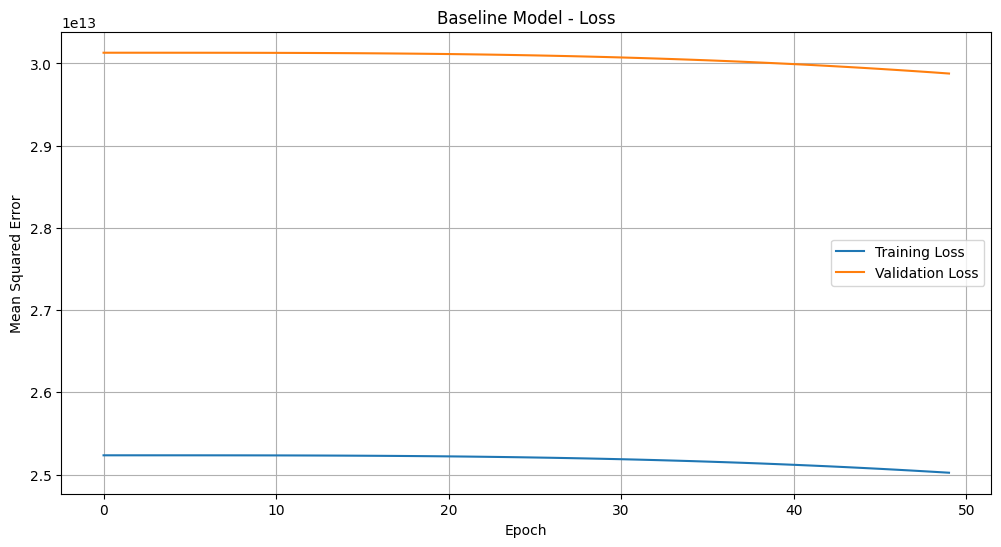

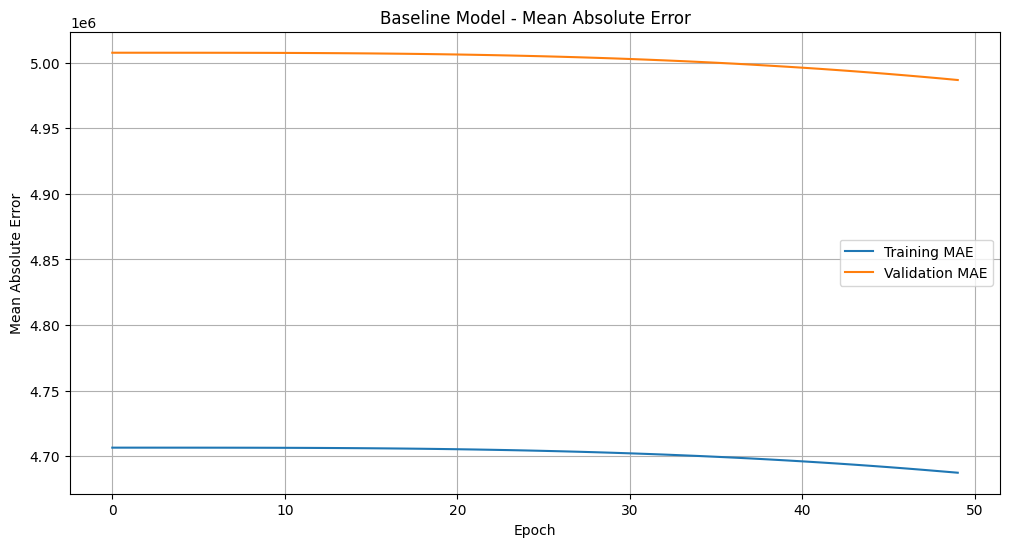

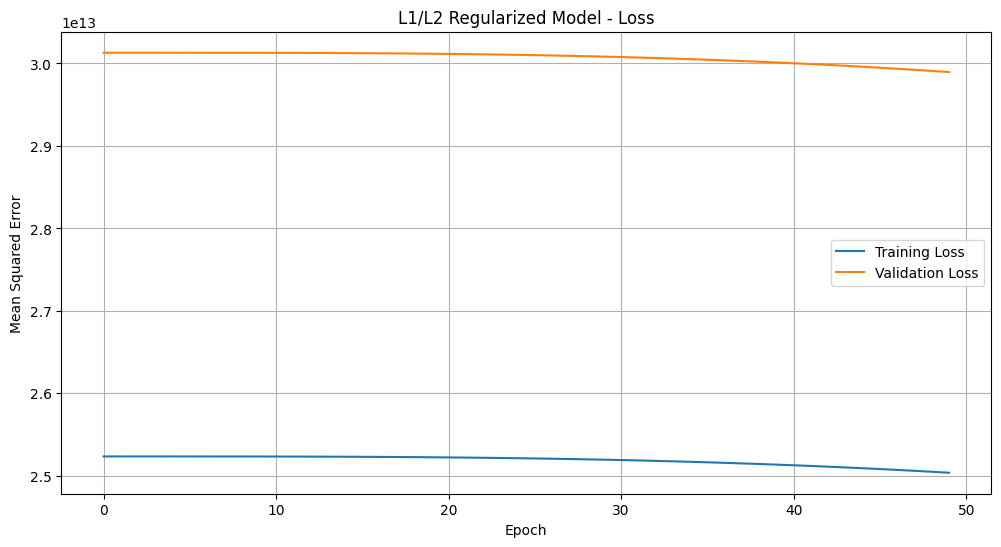

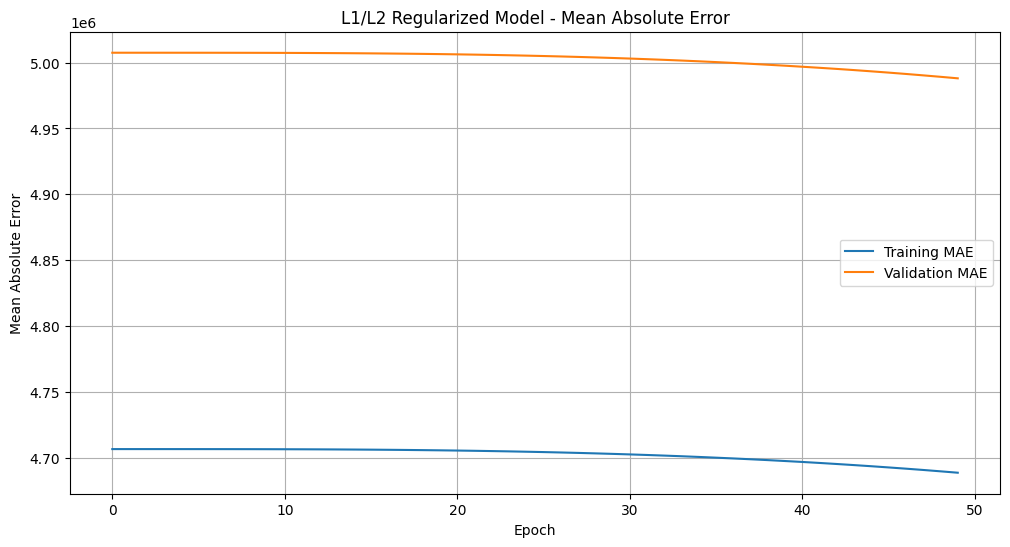


Baseline Model Validation Loss: 29877021442048.0000, MAE: 4986737.5000
L1/L2 Regularized Model Validation Loss: 29895488962560.0000, MAE: 4988090.0000


In [6]:
def plot_history(history, title):
    plt.figure(figsize=(12, 6))
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title(title + ' - Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Mean Squared Error')
    plt.legend()
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(12, 6))
    plt.plot(history.history['mae'], label='Training MAE')
    plt.plot(history.history['val_mae'], label='Validation MAE')
    plt.title(title + ' - Mean Absolute Error')
    plt.xlabel('Epoch')
    plt.ylabel('Mean Absolute Error')
    plt.legend()
    plt.grid(True)
    plt.show()

plot_history(history_baseline, 'Baseline Model')
plot_history(history_regularized, 'L1/L2 Regularized Model')

# Evaluate final performance on validation set
loss_baseline, mae_baseline = baseline_model.evaluate(X_val, y_val, verbose=0)
loss_regularized, mae_regularized = regularized_model.evaluate(X_val, y_val, verbose=0)

print(f"\nBaseline Model Validation Loss: {loss_baseline:.4f}, MAE: {mae_baseline:.4f}")
print(f"L1/L2 Regularized Model Validation Loss: {loss_regularized:.4f}, MAE: {mae_regularized:.4f}")

## 5. Build and Train Model with Dropout Regularization

Now, let's implement Dropout regularization to see its effect on the model's performance and overfitting.

In [7]:
def build_dropout_model(input_shape, dropout_rate=0.3):
    model = keras.Sequential([
        layers.Dense(64, activation='relu', input_shape=[input_shape]),
        layers.Dropout(dropout_rate),
        layers.Dense(64, activation='relu'),
        layers.Dropout(dropout_rate),
        layers.Dense(1)
    ])
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return model

# Build the dropout model
dropout_model = build_dropout_model(input_shape)

dropout_model.summary()

# Train the dropout model
history_dropout = dropout_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=32,
    verbose=0 # Suppress verbose output during training
)

print("Dropout model trained.")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_9 (Dense)                 │ (None, 64)             │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,121 (20.00 KB)

 Trainable params: 5,121 (20.00 KB)

 Non-trainable params: 0 (0.00 B)

Dropout model trained.


## 6. Hyperparameter Tuning and Model Optimization

In [8]:
def build_tuned_model(input_shape,
                      learning_rate=0.001,
                      optimizer='adam',
                      activation='relu',
                      hidden_layers=2):

    model = keras.Sequential()

    model.add(layers.Input(shape=(input_shape,)))
    model.add(layers.Dense(64, activation=activation))

    for _ in range(hidden_layers - 1):
        model.add(layers.Dense(64, activation=activation))

    model.add(layers.Dense(1))

    if optimizer == 'adam':
        opt = keras.optimizers.Adam(learning_rate=learning_rate)

    elif optimizer == 'sgd':
        opt = keras.optimizers.SGD(learning_rate=learning_rate)

    elif optimizer == 'rmsprop':
        opt = keras.optimizers.RMSprop(learning_rate=learning_rate)

    model.compile(
        optimizer=opt,
        loss='mse',
        metrics=['mae']
    )

    return model


experiments = [

    {
        "name": "Original",
        "lr":0.001,
        "batch":32,
        "layers":2,
        "activation":"relu",
        "optimizer":"adam"
    },

    {
        "name":"Adam + Small LR",
        "lr":0.0005,
        "batch":32,
        "layers":2,
        "activation":"relu",
        "optimizer":"adam"
    },

    {
        "name":"SGD",
        "lr":0.01,
        "batch":32,
        "layers":2,
        "activation":"relu",
        "optimizer":"sgd"
    },

    {
        "name":"RMSProp",
        "lr":0.001,
        "batch":32,
        "layers":2,
        "activation":"relu",
        "optimizer":"rmsprop"
    },

    {
        "name":"Extra Layer",
        "lr":0.001,
        "batch":32,
        "layers":3,
        "activation":"relu",
        "optimizer":"adam"
    },

    {
        "name":"Tanh",
        "lr":0.001,
        "batch":32,
        "layers":2,
        "activation":"tanh",
        "optimizer":"adam"
    },

    {
        "name":"Batch Size 64",
        "lr":0.001,
        "batch":64,
        "layers":2,
        "activation":"relu",
        "optimizer":"adam"
    }
]

results = []

histories = {}

for exp in experiments:

    print(f"Training {exp['name']}...")

    model = build_tuned_model(
        input_shape=input_shape,
        learning_rate=exp["lr"],
        optimizer=exp["optimizer"],
        activation=exp["activation"],
        hidden_layers=exp["layers"]
    )

    history = model.fit(
        X_train,
        y_train,
        validation_data=(X_val, y_val),
        epochs=50,
        batch_size=exp["batch"],
        verbose=0
    )

    loss, mae = model.evaluate(X_val, y_val, verbose=0)

    histories[exp["name"]] = history

    results.append({
        "Model":exp["name"],
        "Loss":loss,
        "MAE":mae,
        "RMSE":np.sqrt(loss)
    })

Training Original...
Training Adam + Small LR...
Training SGD...
Training RMSProp...
Training Extra Layer...
Training Tanh...
Training Batch Size 64...


## 7. Display Results

In [9]:
results_df = pd.DataFrame(results)

results_df = results_df.sort_values("MAE")

print(results_df)

             Model          Loss        MAE          RMSE
4      Extra Layer  1.057357e+13  2913217.0  3.251703e+06
0         Original  2.987141e+13  4986424.5  5.465474e+06
3          RMSProp  3.008438e+13  5003746.0  5.484923e+06
1  Adam + Small LR  3.009435e+13  5004547.5  5.485832e+06
6    Batch Size 64  3.009799e+13  5004933.5  5.486163e+06
5             Tanh  3.012939e+13  5007476.5  5.489025e+06
2              SGD           NaN        NaN           NaN


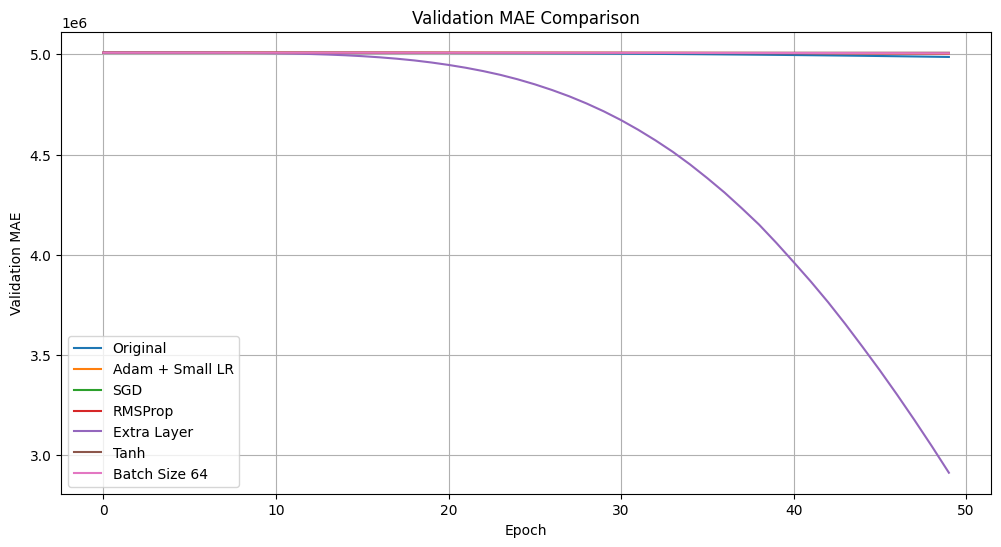

In [10]:
plt.figure(figsize=(12,6))

for name, history in histories.items():
    plt.plot(history.history["val_mae"], label=name)

plt.title("Validation MAE Comparison")
plt.xlabel("Epoch")
plt.ylabel("Validation MAE")
plt.legend()
plt.grid(True)
plt.show()

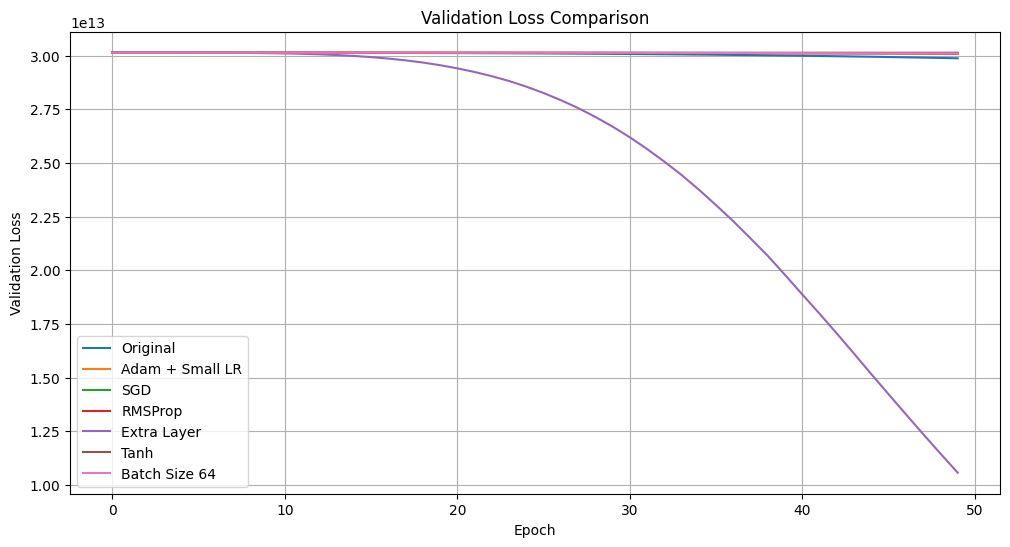

In [11]:
plt.figure(figsize=(12,6))

for name, history in histories.items():
    plt.plot(history.history["val_loss"], label=name)

plt.title("Validation Loss Comparison")
plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

## 8. Model Comparison

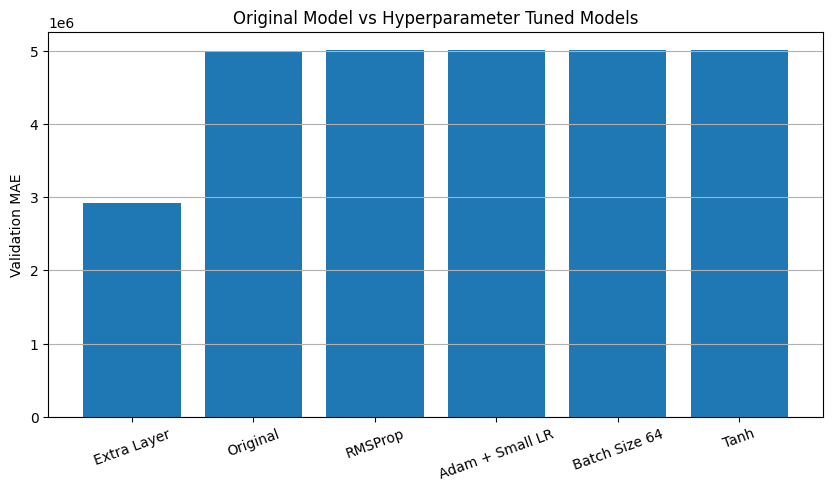

In [12]:
plt.figure(figsize=(10,5))

plt.bar(results_df["Model"], results_df["MAE"])

plt.title("Original Model vs Hyperparameter Tuned Models")
plt.ylabel("Validation MAE")
plt.xticks(rotation=20)
plt.grid(axis="y")

plt.show()